# DermaVision AI
## Explainable Skin Lesion Classification and Segmentation

**Mentee:** Disha Agarwal  

**Mentor:** Viren Mehta  

### Project Objective

This project develops an end-to-end deep learning pipeline that:

1. classifies a dermoscopic image into a skin lesion category,
2. segments the visible lesion region at the pixel level,
3. calculates the percentage of the image occupied by the predicted lesion, and
4. combines the classification and segmentation outputs into an interpretable visual summary.

## 1. Problem  and  Solution

### Problem

Skin lesions can appear similar in colour, shape, texture, and size, even when they belong to different medical categories. This makes visual assessment difficult, especially during early screening. Manual examination also depends on clinical expertise and may vary between observers.

Many existing computer-vision projects perform only one task:

- **Classification models** predict the type of lesion but do not identify its exact location.
- **Segmentation models** locate the affected region but do not provide a lesion category.

Therefore, a single prediction alone may not provide enough visual context to understand the model's output. There is a need for an integrated and interpretable system that can analyse both the category and spatial extent of a skin lesion.

###  Solution

This project proposes **DermaVision AI**, an integrated deep-learning pipeline for analysing dermoscopic skin images.

The system performs three connected tasks:

1. **Skin Lesion Classification:**  
   Predicts the most likely lesion category along with a confidence score.

2. **Lesion Segmentation:**  
   Identifies the lesion region at the pixel level and generates a segmentation mask.

3. **Integrated Visual Analysis:**  
   Combines the classification result and segmentation mask to calculate the approximate lesion-area percentage and generate an interpretable visual output.

### Project Workflow

`Input Dermoscopic Image → Image Preprocessing → Lesion Classification → Lesion Segmentation → Lesion-Area Calculation → Combined Visual Summary`

The final output includes:

- predicted lesion category,
- classification confidence,
- predicted lesion boundary,
- segmentation-mask overlay,
- approximate percentage of the image occupied by the lesion, and
- alternative high-probability predictions.

This project is designed as an **AI-assisted research and screening prototype**. It demonstrates how classification and segmentation can be combined to create a more informative medical-image analysis pipeline. It is not intended to replace clinical examination or diagnosis by a dermatologist.

In [8]:

!pip install -q ultralytics scikit-learn pyyaml


import os
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Deep learning
import torch
from ultralytics import YOLO

# Dataset configuration
import yaml

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU is not enabled. Go to Runtime → Change runtime type → T4 GPU."
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Dataset Description and Selection

### Dataset Source

This project uses the **Skin Lesion Segmentation and Classification Dataset** published by MakhResearch on Hugging Face.

The dataset contains dermoscopic skin-lesion images divided into three predefined subsets:

- **Training set:** 6,675 images
- **Validation set:** 1,911 images
- **Test set:** 961 images
- **Total:** 9,547 images

Each image has a corresponding YOLO-format annotation file containing the lesion class and its spatial coordinates.

### Lesion Categories

The dataset contains seven skin-lesion categories:

| Class ID | Code | Full Name |
|---:|---|---|
| 0 | BKL | Benign Keratosis-like Lesion |
| 1 | NV | Melanocytic Nevus |
| 2 | DF | Dermatofibroma |
| 3 | MEL | Melanoma |
| 4 | VASC | Vascular Lesion |
| 5 | BCC | Basal Cell Carcinoma |
| 6 | AKIEC | Actinic Keratosis / Intraepithelial Carcinoma |

### Annotation Format

Each annotation is stored in a text file using the YOLO format:

`class_id x1 y1 x2 y2 x3 y3 ... xn yn`

Here:

- `class_id` represents the lesion category.
- The remaining values represent normalized polygon coordinates outlining the lesion.
- Normalized coordinates lie between `0` and `1`, making them independent of the original image dimensions.

### Why was this dataset selected?

This dataset was selected because:

1. it contains both lesion-category information and spatial annotations;
2. the same images can therefore be used for classification and segmentation;
3. it already contains separate training, validation, and test sets;
4. its seven classes include both benign and malignant lesion categories;
5. its YOLO-compatible annotations can be used directly with modern deep-learning models.

Using the same source dataset for both tasks reduces domain mismatch between the classification and segmentation models.

### Important Validation Step

Before model training, the dataset structure and annotations will be verified programmatically and visually. This is necessary because a model may train without producing an error even when the class mapping, image-label pairing, or polygon annotations are incorrect.

In [9]:
# Import Path for handling file and folder locations
from pathlib import Path

# Online location of the dataset ZIP file
DATA_URL = (
    "https://huggingface.co/datasets/makhresearch/"
    "skin-lesion-segmentation-classification/resolve/main/"
    "skin-lesion-segmentation-classification.zip"
)

# Location where the downloaded ZIP file will be saved
ZIP_PATH = Path("/content/skin_lesion_dataset.zip")

# Folder where the dataset will be extracted
DATASET_FOLDER = Path("/content/skin_lesion_dataset")


# Download the dataset only if it is not already present
if not ZIP_PATH.exists():
    print("Downloading the dataset...")
    !wget -q --show-progress "$DATA_URL" -O "$ZIP_PATH"
else:
    print("Dataset ZIP file already exists.")


# Extract the dataset only if the folder is not already present
if not DATASET_FOLDER.exists():
    print("Extracting the dataset...")

    DATASET_FOLDER.mkdir(
        parents=True,
        exist_ok=True
    )

    !unzip -q "$ZIP_PATH" -d "$DATASET_FOLDER"

    print("Dataset extracted successfully.")
else:
    print("Extracted dataset folder already exists.")


print("ZIP file location:", ZIP_PATH)
print("Extracted dataset location:", DATASET_FOLDER)

/content/skin_lesio 100%[===================>] 293.53M  29.9MB/s    in 9.1s    
Extracting the dataset...
Dataset extracted successfully.
ZIP file location: /content/skin_lesion_dataset.zip
Extracted dataset location: /content/skin_lesion_dataset


## 4. Dataset Structure Verification

After extracting the dataset, its folder structure must be inspected before model training.

This step verifies that:

- training, validation, and test folders are present;
- every subset contains separate image and label directories;
- the number of images and annotation files is reasonable;
- images and labels have matching filenames.

This validation prevents model-training errors caused by incorrect paths, missing annotations, or incomplete extraction.

In [10]:
# Display the main folders present inside the extracted dataset
print("Main folders inside the extracted dataset:\n")

for folder in sorted(DATASET_FOLDER.rglob("*")):

    # Show only directories, not every individual image file
    if folder.is_dir():

        # Find the folder's location relative to DATASET_FOLDER
        relative_path = folder.relative_to(DATASET_FOLDER)

        # Display only the first three folder levels
        if len(relative_path.parts) <= 3:
            print("📁", relative_path)


# Function to locate the actual dataset root folder
def find_dataset_root(base_folder):
    """
    Find the folder containing train, valid and test directories.
    """

    # Search the base folder and all folders inside it
    candidate_folders = [base_folder]

    candidate_folders += [
        folder
        for folder in base_folder.rglob("*")
        if folder.is_dir()
    ]

    for candidate in candidate_folders:

        required_folders = [
            candidate / "train" / "images",
            candidate / "train" / "labels",
            candidate / "valid" / "images",
            candidate / "valid" / "labels",
            candidate / "test" / "images",
            candidate / "test" / "labels"
        ]

        # Check whether all required folders exist
        if all(folder.exists() for folder in required_folders):
            return candidate

    raise FileNotFoundError(
        "Could not find the expected train, valid and test folders."
    )


# Automatically locate the actual dataset folder
DATASET_ROOT = find_dataset_root(DATASET_FOLDER)

print("\nDataset root found at:")
print(DATASET_ROOT)


# Image extensions that may be present in the dataset
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


# Count and verify images and labels in each split
for split in ["train", "valid", "test"]:

    image_folder = DATASET_ROOT / split / "images"
    label_folder = DATASET_ROOT / split / "labels"

    image_files = [
        file
        for file in image_folder.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    label_files = list(label_folder.glob("*.txt"))

    # Compare filenames without their extensions
    image_names = {file.stem for file in image_files}
    label_names = {file.stem for file in label_files}

    images_without_labels = image_names - label_names
    labels_without_images = label_names - image_names

    print(f"\n{split.upper()} SET")
    print("Number of images:", len(image_files))
    print("Number of labels:", len(label_files))
    print("Images without labels:", len(images_without_labels))
    print("Labels without images:", len(labels_without_images))

Main folders inside the extracted dataset:

📁 skin-lesion-segmentation-classification
📁 skin-lesion-segmentation-classification/test
📁 skin-lesion-segmentation-classification/test/images
📁 skin-lesion-segmentation-classification/test/labels
📁 skin-lesion-segmentation-classification/train
📁 skin-lesion-segmentation-classification/train/images
📁 skin-lesion-segmentation-classification/train/labels
📁 skin-lesion-segmentation-classification/valid
📁 skin-lesion-segmentation-classification/valid/images
📁 skin-lesion-segmentation-classification/valid/labels

Dataset root found at:
/content/skin_lesion_dataset/skin-lesion-segmentation-classification

TRAIN SET
Number of images: 6675
Number of labels: 6675
Images without labels: 0
Labels without images: 0

VALID SET
Number of images: 1911
Number of labels: 1911
Images without labels: 0
Labels without images: 0

TEST SET
Number of images: 961
Number of labels: 961
Images without labels: 0
Labels without images: 0


## 5. Understanding and Visualizing YOLO Annotations

Each dermoscopic image has a corresponding text annotation file with the same filename.

For example:

`ISIC_001.jpg → ISIC_001.txt`

Each line of the annotation file follows the format:

`class_id x1 y1 x2 y2 x3 y3 ... xn yn`

The first value represents the lesion category. The remaining values are pairs of normalized x- and y-coordinates that form a polygon around the lesion.

Since the coordinates are normalized between 0 and 1, they must be multiplied by the image width and height before being displayed in pixel coordinates.

In this section, one annotation file is read and its polygon is drawn over the corresponding image. This visual verification confirms that the class label and lesion boundary are correctly aligned with the image.

In [11]:
# Training images aur labels ke folders
image_folder = DATASET_ROOT / "train" / "images"
label_folder = DATASET_ROOT / "train" / "labels"

# Saari text annotation files ki list
label_files = sorted(label_folder.glob("*.txt"))

# Pehli annotation file select karna
label_path = label_files[0]

# Same naam wali image search karna
image_path = image_folder / f"{label_path.stem}.jpg"

print("Label file:", label_path.name)
print("Image file:", image_path.name)

Label file: ISIC_0024307.txt
Image file: ISIC_0024307.jpg


In [12]:
# Annotation file ko read karna
annotation_text = label_path.read_text()

print("Annotation file content:\n")
print(annotation_text)

Annotation file content:

5 0.5421883328125 0.1687511109375 0.5359383328125 0.175 0.5359383328125 0.17656222187499998 0.53125 0.1812511109375 0.53125 0.1828133328125 0.528125 0.185937778125 0.528125 0.1875 0.525 0.19062444375 0.525 0.1921866671875 0.5171883328125 0.2 0.5171883328125 0.201562221875 0.5125 0.20625111093749998 0.5125 0.20781333281249997 0.509375 0.210937778125 0.509375 0.2125 0.5078133328125001 0.21406222187499999 0.5078133328125001 0.21562444374999998 0.50625 0.21718666718750002 0.50625 0.2187511109375 0.49375 0.2312511109375 0.4921883328125 0.2312511109375 0.490625 0.2328133328125 0.490625 0.23437555625 0.48906333281250003 0.235937778125 0.48906333281250003 0.23906222187499998 0.4875 0.24062444374999997 0.4875 0.24687555625000002 0.48593833281250004 0.248437778125 0.48593833281250004 0.25312444375 0.4875 0.2546866671875 0.4875 0.25937555625000003 0.48906333281250003 0.260937778125 0.48906333281250003 0.275 0.4875 0.276562221875 0.4875 0.30312444374999997 0.4859383328125

In [13]:
# Mapping each numerical class ID to its short lesion name
CLASS_NAMES = {
    0: "BKL",
    1: "NV",
    2: "DF",
    3: "MEL",
    4: "VASC",
    5: "BCC",
    6: "AKIEC"
}

# Full medical names for easier interpretation
CLASS_FULL_NAMES = {
    0: "Benign Keratosis-like Lesion",
    1: "Melanocytic Nevus",
    2: "Dermatofibroma",
    3: "Melanoma",
    4: "Vascular Lesion",
    5: "Basal Cell Carcinoma",
    6: "Actinic Keratosis / Intraepithelial Carcinoma"
}

print("Class mapping created successfully.")

Class mapping created successfully.


In [14]:
# Remove extra spaces and divide the annotation into separate values
values = annotation_text.strip().split()

# The first value represents the lesion class
class_id = int(values[0])

# All remaining values represent polygon coordinates
coordinates = list(map(float, values[1:]))

# Combine consecutive x and y values into coordinate pairs
normalized_points = list(
    zip(
        coordinates[0::2],
        coordinates[1::2]
    )
)

print("Class ID:", class_id)
print("Class name:", CLASS_NAMES[class_id])
print("Number of coordinate values:", len(coordinates))
print("Number of polygon points:", len(normalized_points))

print("\nFirst five normalized points:")
for point in normalized_points[:5]:
    print(point)

Class ID: 5
Class name: BCC
Number of coordinate values: 772
Number of polygon points: 386

First five normalized points:
(0.5421883328125, 0.1687511109375)
(0.5359383328125, 0.175)
(0.5359383328125, 0.17656222187499998)
(0.53125, 0.1812511109375)
(0.53125, 0.1828133328125)


In [15]:
# Open the selected dermoscopic image
image = Image.open(image_path).convert("RGB")

# Obtain the original image dimensions
image_width, image_height = image.size

# Convert normalized polygon points into pixel coordinates
pixel_points = []

for normalized_x, normalized_y in normalized_points:

    pixel_x = int(normalized_x * image_width)
    pixel_y = int(normalized_y * image_height)

    pixel_points.append((pixel_x, pixel_y))


print("Image width:", image_width)
print("Image height:", image_height)
print("Number of pixel points:", len(pixel_points))

print("\nFirst five pixel points:")
for point in pixel_points[:5]:
    print(point)

Image width: 640
Image height: 640
Number of pixel points: 386

First five pixel points:
(347, 108)
(343, 112)
(343, 112)
(340, 116)
(340, 117)


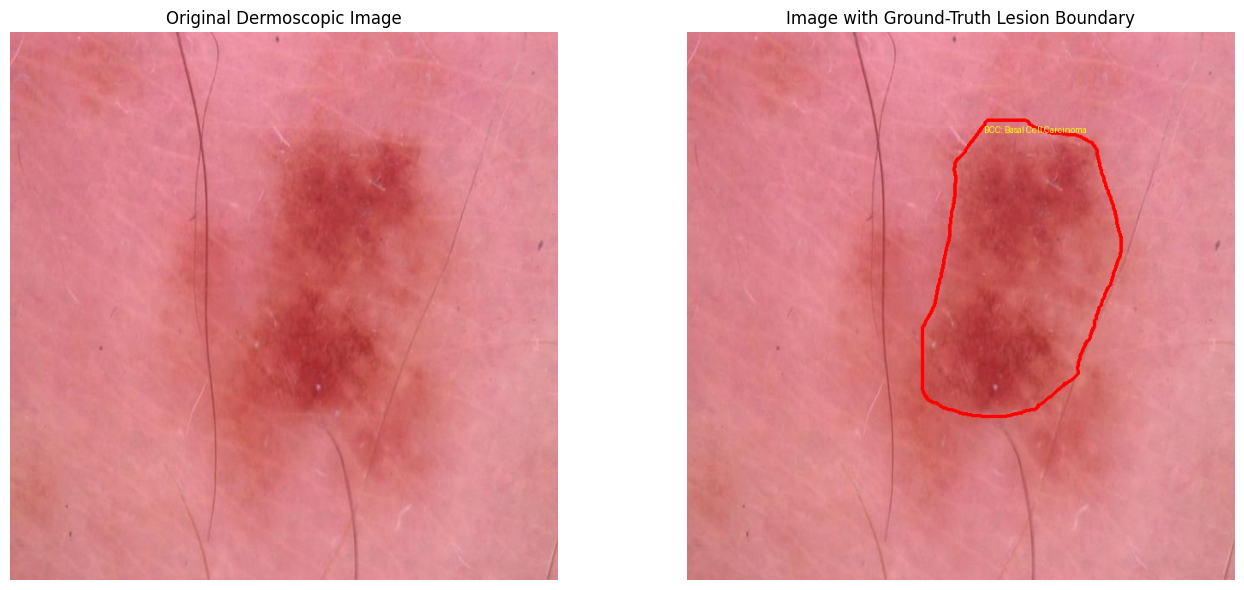

In [16]:
# Create a copy so that the original image remains unchanged
annotated_image = image.copy()

# Create a drawing object for the copied image
draw = ImageDraw.Draw(annotated_image)

# Connect all polygon points to form the lesion boundary
draw.line(
    pixel_points + [pixel_points[0]],
    fill="red",
    width=4
)

# Write the lesion class near the first polygon point
label_text = (
    f"{CLASS_NAMES[class_id]}: "
    f"{CLASS_FULL_NAMES[class_id]}"
)

draw.text(
    pixel_points[0],
    label_text,
    fill="yellow"
)

# Display the original and annotated images side by side
figure, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].set_title("Original Dermoscopic Image")
axes[0].axis("off")

axes[1].imshow(annotated_image)
axes[1].set_title("Image with Ground-Truth Lesion Boundary")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Class Distribution Analysis

Medical-image datasets are often imbalanced, meaning that some disease categories contain many more images than others.

A model trained on an imbalanced dataset may become biased toward the majority class. It can obtain a high overall accuracy while performing poorly on rare but clinically important classes.

Therefore, the number of images belonging to each lesion category is calculated separately for the training, validation, and test sets.

In [17]:
# Store the number of images belonging to each class
class_distribution = {
    "train": Counter(),
    "valid": Counter(),
    "test": Counter()
}


# Analyse every dataset split separately
for split in ["train", "valid", "test"]:

    label_folder = DATASET_ROOT / split / "labels"

    # Read every annotation file inside the split
    for label_path in label_folder.glob("*.txt"):

        annotation_lines = [
            line
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        # Ignore empty annotation files
        if len(annotation_lines) == 0:
            continue

        # Read the class ID from the first annotation line
        first_annotation = annotation_lines[0].split()
        class_id = int(first_annotation[0])

        # Increase the count of that class
        class_distribution[split][class_id] += 1


# Convert the counts into a table
distribution_table = pd.DataFrame({
    split: {
        CLASS_NAMES[class_id]: class_distribution[split][class_id]
        for class_id in CLASS_NAMES
    }
    for split in ["train", "valid", "test"]
})


print("Number of images in each lesion category:")
display(distribution_table)

Number of images in each lesion category:


,train,valid,test
BKL,217,73,36
NV,361,98,55
DF,446,126,64
MEL,82,21,12
VASC,782,216,115
BCC,4681,1356,664
AKIEC,106,21,15


## 7. Class Imbalance Visualization

The class distribution is visualized to determine whether some lesion categories dominate the dataset.

Class imbalance is important because a model may learn to predict frequently occurring classes more often while ignoring rare categories. In medical-image analysis, this can be especially problematic because a rare class may still be clinically significant.

The majority-to-minority ratio is also calculated:

\[
\text{Imbalance Ratio}
=
\frac{\text{Number of images in the largest class}}
{\text{Number of images in the smallest class}}
\]

A larger ratio indicates stronger class imbalance.

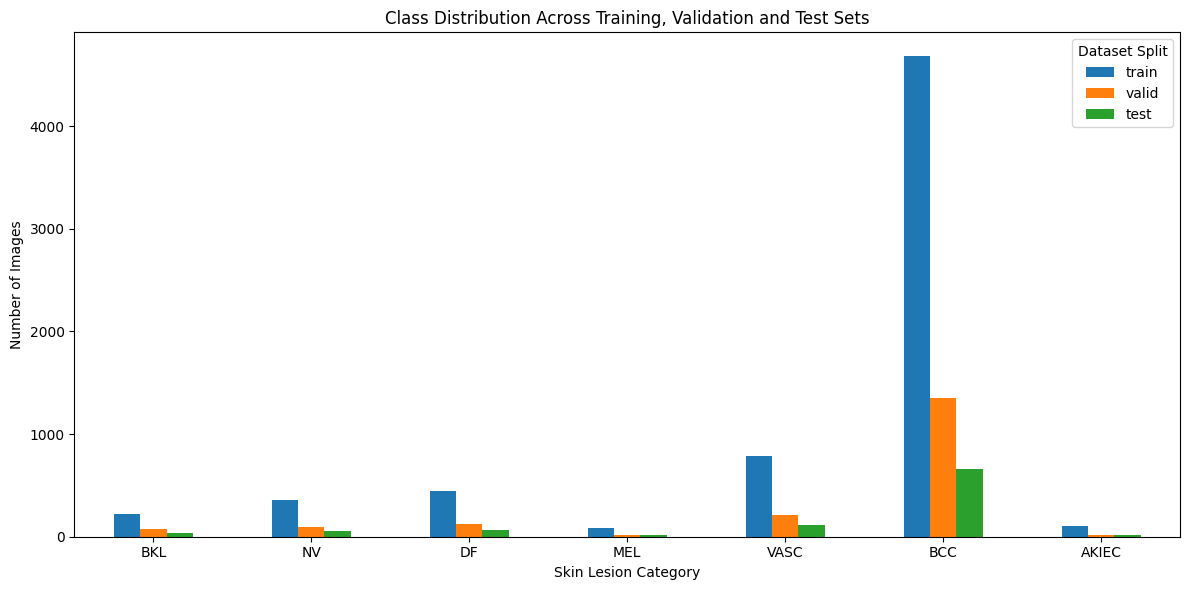

Largest training class: BCC
Number of images: 4681

Smallest training class: MEL
Number of images: 82

Majority-to-minority imbalance ratio: 57.09:1


In [18]:
# Arrange the class names in their correct numerical order
ordered_class_names = [
    CLASS_NAMES[class_id]
    for class_id in sorted(CLASS_NAMES)
]

# Reorder the table before plotting
distribution_table = distribution_table.loc[
    ordered_class_names
]

# Plot the class distribution of all three dataset splits
distribution_table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Class Distribution Across Training, Validation and Test Sets"
)
plt.xlabel("Skin Lesion Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Dataset Split")
plt.tight_layout()
plt.show()


# Calculate the imbalance ratio using the training set
training_counts = distribution_table["train"]

largest_class = training_counts.idxmax()
smallest_class = training_counts.idxmin()

largest_count = training_counts.max()
smallest_count = training_counts.min()

imbalance_ratio = largest_count / smallest_count


print("Largest training class:", largest_class)
print("Number of images:", largest_count)

print("\nSmallest training class:", smallest_class)
print("Number of images:", smallest_count)

print(
    f"\nMajority-to-minority imbalance ratio: "
    f"{imbalance_ratio:.2f}:1"
)

## 8. Annotation Quality and Consistency Check

A single visual example cannot confirm that the entire dataset is correctly annotated. Therefore, all annotation files are checked programmatically before model training.

The validation checks for:

- empty annotation files,
- unknown class IDs,
- incomplete coordinate pairs,
- polygons containing fewer than three points, and
- images containing annotations from multiple lesion classes.

This step helps identify data-quality issues that could otherwise affect model training and evaluation.

In [19]:
# Store the annotation-quality results for every dataset split
annotation_check_results = []


# Check train, validation and test annotations separately
for split in ["train", "valid", "test"]:

    label_folder = DATASET_ROOT / split / "labels"

    total_files = 0
    empty_files = 0
    unknown_class_files = 0
    malformed_polygon_files = 0
    multiple_class_files = 0


    # Read every annotation file in the current split
    for label_path in label_folder.glob("*.txt"):

        total_files += 1

        # Read all non-empty annotation lines
        annotation_lines = [
            line.strip()
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]


        # Check 1: Is the annotation file empty?
        if len(annotation_lines) == 0:
            empty_files += 1
            continue


        classes_in_image = set()
        file_has_unknown_class = False
        file_has_malformed_polygon = False


        # Check every polygon stored in the annotation file
        for annotation in annotation_lines:

            values = annotation.split()

            # The first value should be the class ID
            class_id = int(float(values[0]))

            classes_in_image.add(class_id)


            # Check 2: Is the class ID present in our class mapping?
            if class_id not in CLASS_NAMES:
                file_has_unknown_class = True


            # All remaining values should represent x-y coordinate pairs
            coordinates = values[1:]


            # A polygon needs at least 3 points = 6 coordinate values
            if (
                len(coordinates) < 6
                or len(coordinates) % 2 != 0
            ):
                file_has_malformed_polygon = True


        # Count each problematic file only once
        if file_has_unknown_class:
            unknown_class_files += 1

        if file_has_malformed_polygon:
            malformed_polygon_files += 1


        # Check 3: Does one image contain multiple lesion classes?
        if len(classes_in_image) > 1:
            multiple_class_files += 1


    annotation_check_results.append({
        "Split": split,
        "Total annotation files": total_files,
        "Empty files": empty_files,
        "Unknown class IDs": unknown_class_files,
        "Malformed polygons": malformed_polygon_files,
        "Multiple-class images": multiple_class_files
    })


# Convert the results into a readable table
annotation_quality_table = pd.DataFrame(
    annotation_check_results
)

display(annotation_quality_table)

,Split,Total annotation files,Empty files,Unknown class IDs,Malformed polygons,Multiple-class images
0,train,6675,0,0,0,0
1,valid,1911,0,0,0,0
2,test,961,0,0,0,0


## 9. Segmentation Dataset Configuration

The segmentation model must know:

- where the dataset is stored,
- which folders contain the training, validation, and test images, and
- the name and order of each lesion category.

This information is stored in a YAML configuration file. During training, YOLO reads this file to locate the images and their corresponding polygon annotations.

In [20]:
# Arrange the class names according to their numerical IDs
class_name_list = [
    CLASS_NAMES[class_id]
    for class_id in sorted(CLASS_NAMES)
]

# Location where the YAML configuration file will be saved
SEGMENTATION_YAML = Path(
    "/content/dermavision_segmentation.yaml"
)

# Information required by the YOLO segmentation model
segmentation_config = {
    "path": str(DATASET_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": class_name_list
}

# Save the configuration as a YAML file
with open(SEGMENTATION_YAML, "w") as yaml_file:
    yaml.safe_dump(
        segmentation_config,
        yaml_file,
        sort_keys=False
    )

print("Segmentation YAML file created successfully.\n")

# Display the content of the created YAML file
print(SEGMENTATION_YAML.read_text())

Segmentation YAML file created successfully.

path: /content/skin_lesion_dataset/skin-lesion-segmentation-classification
train: train/images
val: valid/images
test: test/images
names:
- BKL
- NV
- DF
- MEL
- VASC
- BCC
- AKIEC



## 10. Segmentation Model Selection

For lesion segmentation, this project uses the pretrained **YOLOv8n-seg** model.

YOLO segmentation predicts:

1. the lesion category,
2. a bounding region around the lesion, and
3. a pixel-level mask representing the lesion boundary.

### Why use transfer learning?

Training a deep neural network completely from scratch requires a very large dataset, more computation, and substantially more training time.

The selected model has already learned general visual features from a large image dataset, such as:

- edges,
- curves,
- textures,
- shapes, and
- object boundaries.

The pretrained model is then fine-tuned on dermoscopic images so that these general features are adapted to skin-lesion segmentation.

### Why use the nano model?

YOLO models are available in different sizes. The nano variant is selected because it:

- trains faster,
- uses less GPU memory,
- is suitable for a time-constrained Colab session, and
- provides a practical baseline for the complete pipeline.

Larger variants may produce better results but require greater computation and longer training.

### Initial Training Strategy

The model will first be trained for a limited number of epochs to establish a complete working baseline. Its validation metrics and visual predictions will then be examined before deciding whether additional training or tuning is required.

In [21]:
# Number of times the model will see the complete training dataset
SEGMENTATION_EPOCHS = 8

# Size to which images will be resized during training
SEGMENTATION_IMAGE_SIZE = 416

# Load a pretrained YOLOv8 nano segmentation model
segmentation_model = YOLO("yolov8n-seg.pt")


# Fine-tune the model on the skin-lesion dataset
segmentation_training_results = segmentation_model.train(

    # YAML file containing dataset paths and class names
    data=str(SEGMENTATION_YAML),

    # Number of complete passes through the training dataset
    epochs=SEGMENTATION_EPOCHS,

    # Input image dimensions used during training
    imgsz=SEGMENTATION_IMAGE_SIZE,

    # Number of images processed together in one training step
    batch=16,

    # Use the first available GPU
    device=0,

    # Number of CPU workers used to load images
    workers=2,

    # Stop early if validation performance does not improve
    patience=4,

    # Improve reproducibility
    seed=SEED,

    # Folder in which all training outputs will be saved
    project="/content/dermavision_runs",

    # Name of this particular experiment
    name="segmentation_baseline",

    # Allow the same output folder to be reused
    exist_ok=True,

    # Automatically generate training graphs
    plots=True
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dermavision_segmentation.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=segmentation_baseline, nbs=64, nms=False,

## 11. Loading the Best Segmentation Checkpoint

During training, two model checkpoints are saved:

- `last.pt`, which contains the model obtained after the final epoch;
- `best.pt`, which contains the model that achieved the best validation performance during training.

The best checkpoint is selected for final evaluation because the final epoch is not necessarily the strongest-performing epoch. The selected model will now be evaluated on the held-out test set, which was not used for weight updates or checkpoint selection.

In [22]:
# Path of the best model checkpoint saved during training
BEST_SEGMENTATION_MODEL_PATH = Path(
    "/content/dermavision_runs/"
    "segmentation_baseline/weights/best.pt"
)

# Verify that the checkpoint exists
if not BEST_SEGMENTATION_MODEL_PATH.exists():
    raise FileNotFoundError(
        "The best segmentation checkpoint was not found."
    )

# Load the best-performing segmentation model
best_segmentation_model = YOLO(
    str(BEST_SEGMENTATION_MODEL_PATH)
)

print("Best segmentation model loaded successfully.")
print("Checkpoint:", BEST_SEGMENTATION_MODEL_PATH)

Best segmentation model loaded successfully.
Checkpoint: /content/dermavision_runs/segmentation_baseline/weights/best.pt


## 12. Segmentation Evaluation on the Test Set

The best segmentation checkpoint is evaluated on the held-out test set.

The test set was not used for model training or checkpoint selection, so its results provide a more reliable estimate of model performance on unseen images.

The primary segmentation metrics are:

- **Mask Precision:** reliability of predicted lesion masks;
- **Mask Recall:** proportion of actual lesions successfully detected;
- **Mask mAP50:** mean average precision at an IoU threshold of 0.50;
- **Mask mAP50–95:** mean average precision averaged across stricter IoU thresholds.

In [23]:
# Evaluate the best segmentation model on the unseen test set
segmentation_test_results = best_segmentation_model.val(
    data=str(SEGMENTATION_YAML),
    split="test",
    imgsz=416,
    device=0,
    plots=True
)

# Store the important test metrics
segmentation_metrics = pd.DataFrame({
    "Metric": [
        "Box Precision",
        "Box Recall",
        "Box mAP50",
        "Box mAP50-95",
        "Mask Precision",
        "Mask Recall",
        "Mask mAP50",
        "Mask mAP50-95"
    ],
    "Value": [
        segmentation_test_results.box.p.mean(),
        segmentation_test_results.box.r.mean(),
        segmentation_test_results.box.map50,
        segmentation_test_results.box.map,
        segmentation_test_results.seg.p.mean(),
        segmentation_test_results.seg.r.mean(),
        segmentation_test_results.seg.map50,
        segmentation_test_results.seg.map
    ]
})

display(segmentation_metrics.round(4))

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,429 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 847.7±316.1 MB/s, size: 27.0 KB)
val: Scanning /content/skin_lesion_dataset/skin-lesion-segmentation-classification/test/labels... 961 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 961/961 746.7it/s 1.3s
val: New cache created: /content/skin_lesion_dataset/skin-lesion-segmentation-classification/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 3.8it/s 16.1s
                   all        961       1092      0.537      0.525      0.503      0.409      0.535      0.521        0.5      0.399
                   BKL         36         43      0.438      0.233      0.359      0.242      0.438      0.233      0.357      0.214
                    

,Metric,Value
0,Box Precision,0.5369
1,Box Recall,0.5252
2,Box mAP50,0.5034
3,Box mAP50-95,0.4090
4,Mask Precision,0.5345
5,Mask Recall,0.5210
6,Mask mAP50,0.4996
7,Mask mAP50-95,0.3992


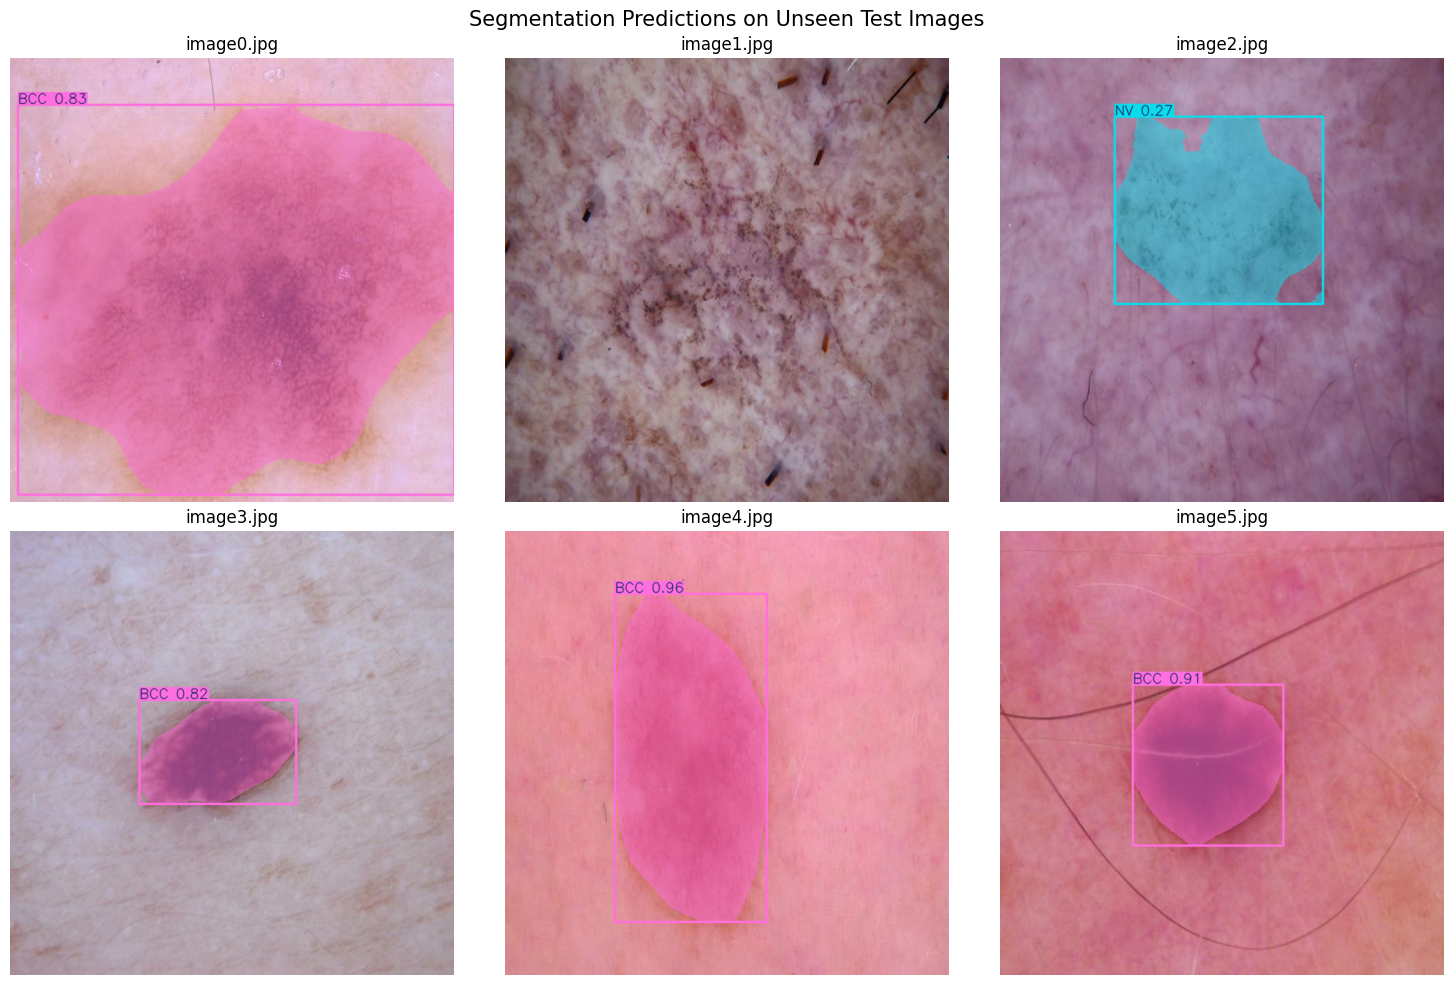

In [24]:
# Collect all test images
test_image_folder = DATASET_ROOT / "test" / "images"

test_images = [
    file
    for file in test_image_folder.iterdir()
    if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

# Select six random unseen images
sample_test_images = random.sample(test_images, 6)

# Generate segmentation predictions
segmentation_predictions = best_segmentation_model.predict(
    source=[str(image) for image in sample_test_images],
    imgsz=416,
    conf=0.25,
    device=0,
    verbose=False
)

# Display predictions
figure, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for axis, result in zip(axes, segmentation_predictions):

    # result.plot() returns an image in BGR format
    prediction_image = result.plot()

    # Convert BGR to RGB for correct display
    prediction_image = cv2.cvtColor(
        prediction_image,
        cv2.COLOR_BGR2RGB
    )

    axis.imshow(prediction_image)
    axis.set_title(Path(result.path).name)
    axis.axis("off")

plt.suptitle(
    "Segmentation Predictions on Unseen Test Images",
    fontsize=15
)
plt.tight_layout()
plt.show()

# Part B — Skin Lesion Classification

## 13. Preparing the Classification Dataset

The original dataset stores lesion classes inside YOLO polygon annotation files. However, an image-classification model expects images to be arranged into class-specific folders.

Therefore, the class ID is extracted from each annotation file and the corresponding image is placed inside its lesion-category folder.

The resulting structure is:

`split / class_name / image`

For example:

`train / BCC / image_001.jpg`

In [25]:
# Folder where the classification dataset will be created
CLASSIFICATION_ROOT = Path(
    "/content/dermavision_classification"
)

# Segmentation dataset uses "valid",
# while classification training expects "val"
split_mapping = {
    "train": "train",
    "valid": "val",
    "test": "test"
}


# Remove an older classification folder if this cell is rerun
if CLASSIFICATION_ROOT.exists():
    shutil.rmtree(CLASSIFICATION_ROOT)


# Create folders for every split and lesion class
for target_split in split_mapping.values():

    for class_name in CLASS_NAMES.values():

        class_folder = (
            CLASSIFICATION_ROOT
            / target_split
            / class_name
        )

        class_folder.mkdir(
            parents=True,
            exist_ok=True
        )


# Store information about the converted images
classification_records = []


# Process training, validation and test images
for source_split, target_split in split_mapping.items():

    image_folder = (
        DATASET_ROOT / source_split / "images"
    )

    label_folder = (
        DATASET_ROOT / source_split / "labels"
    )


    for label_path in label_folder.glob("*.txt"):

        # Read non-empty annotation lines
        annotation_lines = [
            line
            for line in label_path.read_text().splitlines()
            if line.strip()
        ]

        if len(annotation_lines) == 0:
            continue


        # Obtain the lesion class from the first annotation
        class_id = int(
            annotation_lines[0].split()[0]
        )

        class_name = CLASS_NAMES[class_id]


        # Find the corresponding image
        image_path = None

        for extension in [".jpg", ".jpeg", ".png"]:

            possible_image = (
                image_folder
                / f"{label_path.stem}{extension}"
            )

            if possible_image.exists():
                image_path = possible_image
                break


        if image_path is None:
            continue


        # Destination folder based on the lesion class
        destination_path = (
            CLASSIFICATION_ROOT
            / target_split
            / class_name
            / image_path.name
        )


        # Create a hard link to avoid duplicating image data
        try:
            os.link(
                image_path,
                destination_path
            )

        # If hard linking is unavailable, copy the image
        except OSError:
            shutil.copy2(
                image_path,
                destination_path
            )


        classification_records.append({
            "split": target_split,
            "image": image_path.name,
            "class_id": class_id,
            "class_name": class_name
        })


# Convert preparation details into a table
classification_manifest = pd.DataFrame(
    classification_records
)


# Display the number of images in every folder
classification_distribution = (
    classification_manifest
    .groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
)

display(classification_distribution)

print(
    "Classification dataset created at:",
    CLASSIFICATION_ROOT
)

class_name,AKIEC,BCC,BKL,DF,MEL,NV,VASC
split,,,,,,,
test,15,664,36,64,12,55,115
train,106,4681,217,446,82,361,782
val,21,1356,73,126,21,98,216


Classification dataset created at: /content/dermavision_classification


## 14. Classification Model Training

A pretrained YOLOv8 nano classification model is fine-tuned on the prepared skin-lesion dataset.

Unlike segmentation, classification assigns one label to the complete image. The model therefore learns to predict which of the seven lesion categories is most likely to be present.

A lightweight pretrained model is used because it provides a practical balance between training speed and model capacity for a limited Colab session.

In [26]:
# Number of complete passes through the classification dataset
CLASSIFICATION_EPOCHS = 8

# Input image size used by the classifier
CLASSIFICATION_IMAGE_SIZE = 224

# Load a pretrained YOLOv8 nano classification model
classification_model = YOLO("yolov8n-cls.pt")


# Fine-tune the classifier on the skin-lesion dataset
classification_training_results = classification_model.train(

    # Root folder containing train, val and test folders
    data=str(CLASSIFICATION_ROOT),

    # Number of times the model sees the complete training set
    epochs=CLASSIFICATION_EPOCHS,

    # Resize images to 224 × 224 pixels
    imgsz=CLASSIFICATION_IMAGE_SIZE,

    # Number of images processed together
    batch=64,

    # Use the Colab GPU
    device=0,

    # CPU workers for loading images
    workers=2,

    # Stop if validation performance does not improve
    patience=4,

    # Reproducibility
    seed=SEED,

    # Output folder
    project="/content/dermavision_runs",

    # Experiment name
    name="classification_baseline",

    # Reuse the folder if this cell is rerun
    exist_ok=True,

    # Generate training plots
    plots=True
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dermavision_classification, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=classification_baseline, nbs=64, nms=False, 

## 15. Classification Evaluation on the Test Set

The best classification checkpoint is evaluated on the held-out test set.

In addition to overall accuracy, macro F1-score and class-wise precision and recall are calculated. These metrics are important because the dataset is imbalanced, and overall accuracy alone may hide poor performance on less frequent lesion categories.

In [27]:
# Load the best classification checkpoint
BEST_CLASSIFICATION_MODEL_PATH = Path(
    "/content/dermavision_runs/"
    "classification_baseline/weights/best.pt"
)

best_classification_model = YOLO(
    str(BEST_CLASSIFICATION_MODEL_PATH)
)

print("Best classification model loaded successfully.")


# Collect every test image from the class folders
test_classification_images = sorted([
    image_path
    for class_folder in (
        CLASSIFICATION_ROOT / "test"
    ).iterdir()
    if class_folder.is_dir()
    for image_path in class_folder.iterdir()
    if image_path.suffix.lower() in {
        ".jpg", ".jpeg", ".png"
    }
])


true_labels = []
predicted_labels = []
prediction_confidences = []

# Predict in batches to make inference faster
batch_size = 64

for start_index in range(
    0,
    len(test_classification_images),
    batch_size
):
    batch_paths = test_classification_images[
        start_index:start_index + batch_size
    ]

    batch_results = best_classification_model.predict(
        source=[str(path) for path in batch_paths],
        imgsz=224,
        device=0,
        verbose=False
    )

    for image_path, result in zip(
        batch_paths,
        batch_results
    ):
        # Actual class is the parent folder name
        true_class = image_path.parent.name

        # Class with the highest predicted probability
        predicted_id = int(result.probs.top1)
        predicted_class = result.names[predicted_id]

        confidence = float(result.probs.top1conf)

        true_labels.append(true_class)
        predicted_labels.append(predicted_class)
        prediction_confidences.append(confidence)


# Calculate final test metrics
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

test_macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro F1-score: {test_macro_f1:.4f}")

Best classification model loaded successfully.
Test Accuracy: 0.8304
Macro F1-score: 0.6675


## 16. Class-Wise Classification Analysis

Overall accuracy does not show how the model performs on each lesion category. Therefore, precision, recall, and F1-score are calculated separately for every class.

A normalized confusion matrix is also generated to identify which lesion categories are most frequently confused with one another.

,precision,recall,f1-score,support
BKL,0.6774,0.5833,0.6269,36.0000
NV,0.7414,0.7818,0.7611,55.0000
DF,0.5614,0.5000,0.5289,64.0000
MEL,0.6667,0.3333,0.4444,12.0000
VASC,0.5856,0.5652,0.5752,115.0000
BCC,0.9067,0.9367,0.9215,664.0000
AKIEC,0.9167,0.7333,0.8148,15.0000
accuracy,0.8304,0.8304,0.8304,0.8304
macro avg,0.7223,0.6334,0.6675,961.0000
weighted avg,0.8244,0.8304,0.8261,961.0000


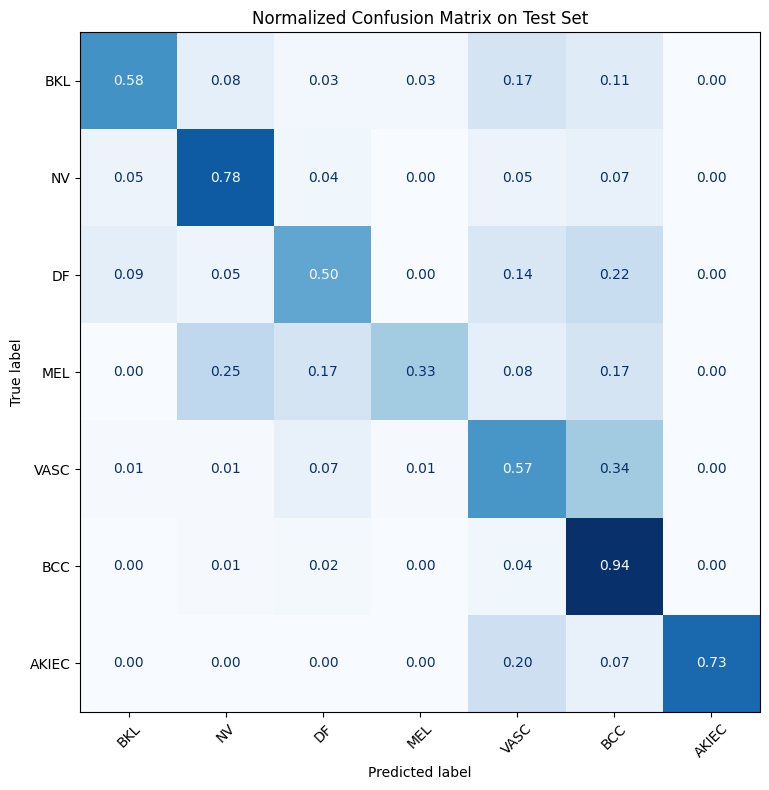

In [28]:
# Keep classes in their numerical order
ordered_classes = [
    CLASS_NAMES[class_id]
    for class_id in sorted(CLASS_NAMES)
]

# Generate class-wise precision, recall and F1-score
classification_report_dictionary = classification_report(
    true_labels,
    predicted_labels,
    labels=ordered_classes,
    output_dict=True,
    zero_division=0
)

classification_report_table = pd.DataFrame(
    classification_report_dictionary
).transpose()

display(classification_report_table.round(4))


# Create a normalized confusion matrix
confusion_matrix_values = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=ordered_classes,
    normalize="true"
)

figure, axis = plt.subplots(figsize=(9, 8))

confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=ordered_classes
)

confusion_matrix_display.plot(
    ax=axis,
    cmap="Blues",
    values_format=".2f",
    colorbar=False
)

plt.title("Normalized Confusion Matrix on Test Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Part C — Integrated DermaVision Pipeline

## 17. Combining Classification and Segmentation

The trained classification and segmentation models are combined into a single inference pipeline.

For a new dermoscopic image, the system:

1. predicts the most likely lesion category;
2. reports the classification confidence and top three predictions;
3. generates a pixel-level lesion mask;
4. overlays the predicted mask on the original image; and
5. calculates the approximate percentage of the image covered by the lesion.

The calculated area percentage is a geometric image measurement. It must not be interpreted as the clinical severity or stage of a disease.

In [29]:
def analyse_skin_image(image_path, display_result=True):
    """
    Run classification and segmentation on one skin-lesion image.
    """

    image_path = Path(image_path)

    # Open the original image
    original_image = Image.open(image_path).convert("RGB")
    original_array = np.array(original_image)

    # ---------------------------------------------------------
    # PART 1: CLASSIFICATION
    # ---------------------------------------------------------

    classification_result = best_classification_model.predict(
        source=str(image_path),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    # Highest-probability class
    predicted_class_id = int(
        classification_result.probs.top1
    )

    predicted_class = classification_result.names[
        predicted_class_id
    ]

    classification_confidence = float(
        classification_result.probs.top1conf
    )

    # Obtain the three highest-probability predictions
    top_three_ids = [
        int(class_id)
        for class_id in classification_result.probs.top5[:3]
    ]

    top_three_predictions = []

    for class_id in top_three_ids:

        class_name = classification_result.names[class_id]

        probability = float(
            classification_result.probs.data[class_id]
        )

        top_three_predictions.append({
            "Class": class_name,
            "Probability": probability
        })

    # ---------------------------------------------------------
    # PART 2: SEGMENTATION
    # ---------------------------------------------------------

    segmentation_result = best_segmentation_model.predict(
        source=str(image_path),
        imgsz=416,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    # Start with an empty lesion mask
    final_mask = np.zeros(
        (
            original_array.shape[0],
            original_array.shape[1]
        ),
        dtype=np.uint8
    )

    # Check whether the model predicted any masks
    if segmentation_result.masks is not None:

        predicted_masks = (
            segmentation_result
            .masks
            .data
            .cpu()
            .numpy()
        )

        # Combine all predicted lesion masks into one mask
        for mask in predicted_masks:

            resized_mask = cv2.resize(
                mask,
                (
                    original_array.shape[1],
                    original_array.shape[0]
                ),
                interpolation=cv2.INTER_NEAREST
            )

            final_mask[
                resized_mask > 0.5
            ] = 1

    # ---------------------------------------------------------
    # PART 3: LESION-AREA CALCULATION
    # ---------------------------------------------------------

    lesion_pixels = np.sum(final_mask)

    total_pixels = (
        original_array.shape[0]
        * original_array.shape[1]
    )

    lesion_area_percentage = (
        lesion_pixels / total_pixels
    ) * 100

    # ---------------------------------------------------------
    # PART 4: CREATE MASK OVERLAY
    # ---------------------------------------------------------

    overlay_image = original_array.copy()

    # Highlight the predicted lesion area
    highlighted_image = original_array.copy()

    highlighted_image[
        final_mask == 1
    ] = [255, 255, 255]

    overlay_image = cv2.addWeighted(
        original_array,
        0.65,
        highlighted_image,
        0.35,
        0
    )

    # Store all final outputs
    result_summary = {
        "Image": image_path.name,
        "Predicted Class": predicted_class,
        "Classification Confidence":
            classification_confidence,
        "Predicted Lesion Area (%)":
            lesion_area_percentage,
        "Number of Predicted Masks":
            0 if segmentation_result.masks is None
            else len(segmentation_result.masks.data)
    }

    # ---------------------------------------------------------
    # DISPLAY THE RESULT
    # ---------------------------------------------------------

    if display_result:

        figure, axes = plt.subplots(
            1,
            2,
            figsize=(13, 6)
        )

        axes[0].imshow(original_array)
        axes[0].set_title(
            "Original Dermoscopic Image"
        )
        axes[0].axis("off")

        axes[1].imshow(overlay_image)
        axes[1].set_title(
            "Predicted Lesion Mask Overlay"
        )
        axes[1].axis("off")

        plt.suptitle(
            f"Predicted Class: {predicted_class}\n"
            f"Confidence: "
            f"{classification_confidence:.2%} | "
            f"Lesion Area: "
            f"{lesion_area_percentage:.2f}%",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()

        print("Top Three Classification Predictions:")

        top_three_table = pd.DataFrame(
            top_three_predictions
        )

        top_three_table["Probability"] = (
            top_three_table["Probability"] * 100
        ).round(2)

        display(top_three_table)

        print(
            "Important: This output is an academic "
            "AI prediction and not a medical diagnosis."
        )

    return result_summary

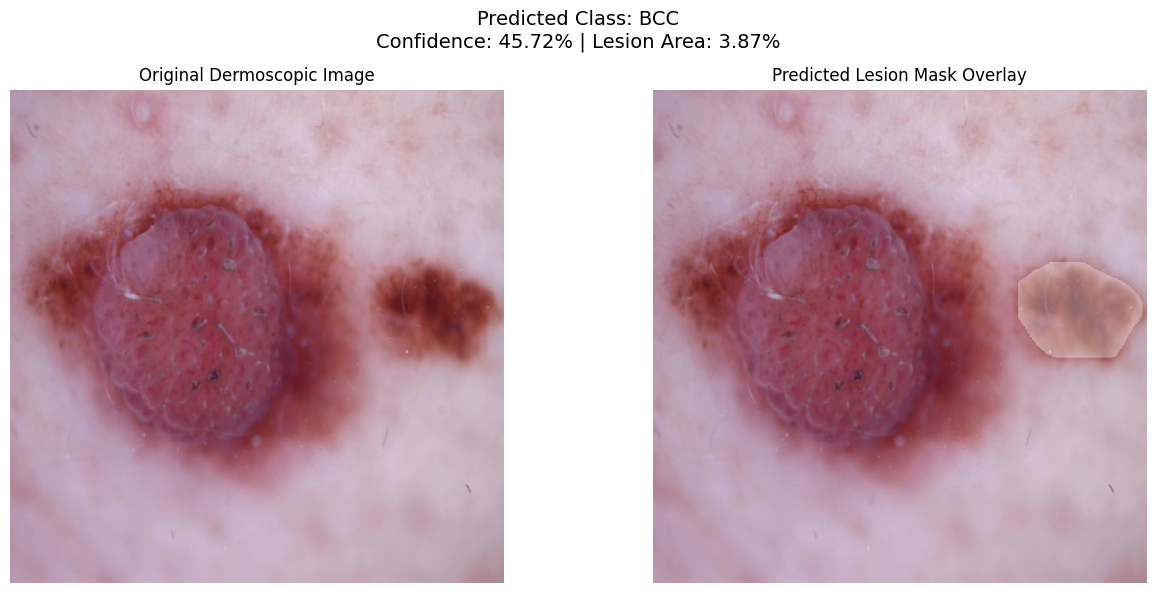

Top Three Classification Predictions:


,Class,Probability
0,BCC,45.72
1,VASC,37.59
2,DF,14.66


Important: This output is an academic AI prediction and not a medical diagnosis.


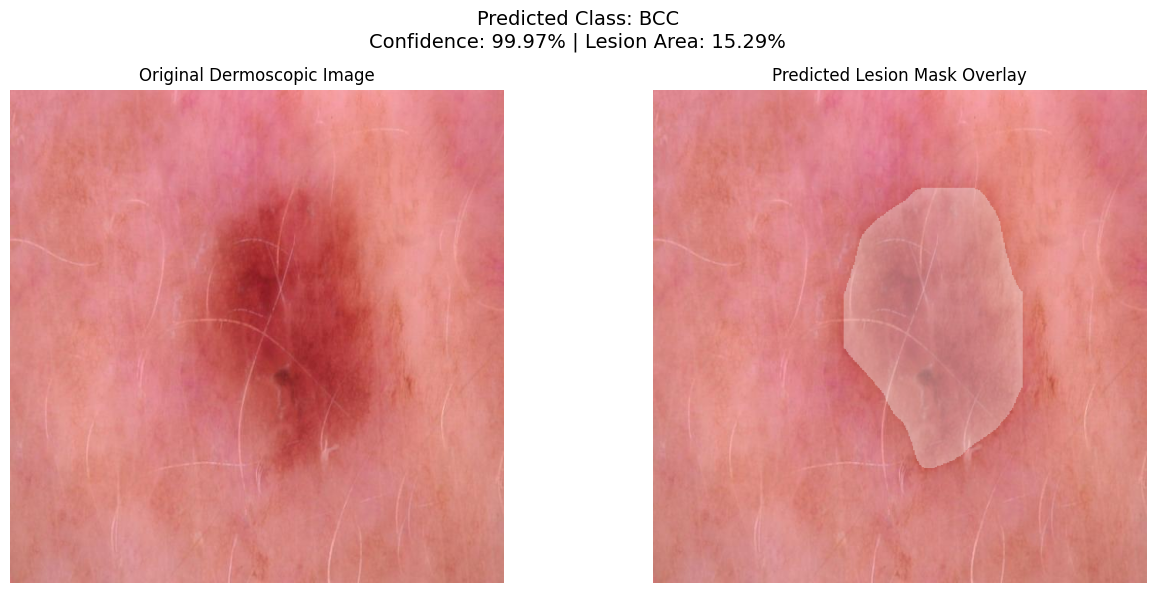

Top Three Classification Predictions:


,Class,Probability
0,BCC,99.97
1,MEL,0.02
2,VASC,0.01


Important: This output is an academic AI prediction and not a medical diagnosis.


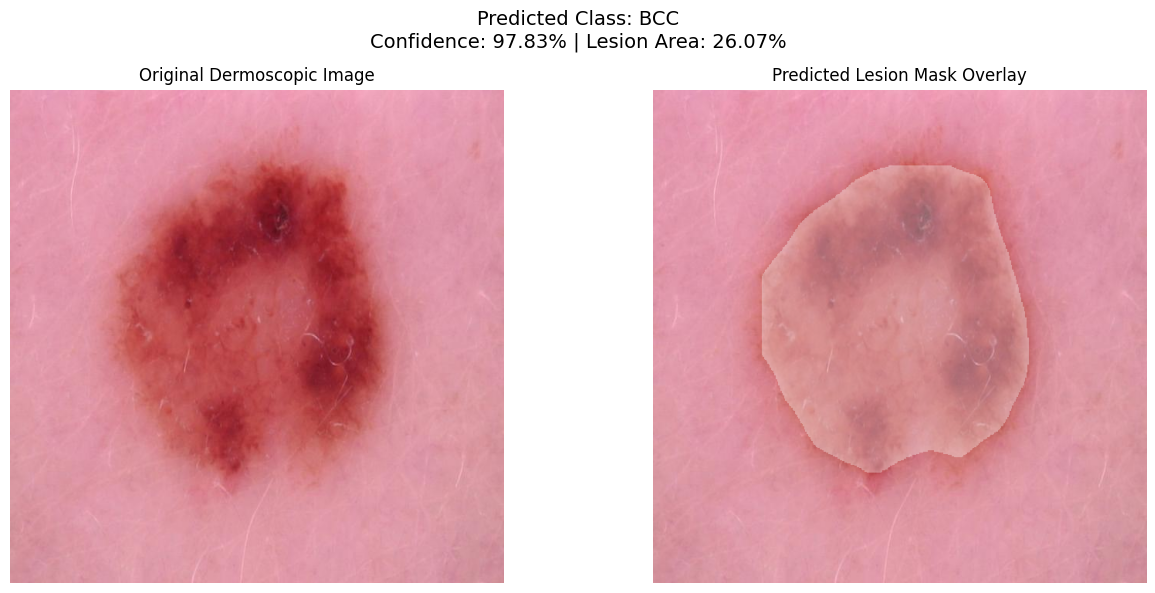

Top Three Classification Predictions:


,Class,Probability
0,BCC,97.83
1,VASC,1.19
2,DF,0.93


Important: This output is an academic AI prediction and not a medical diagnosis.


,Image,Predicted Class,Classification Confidence,Predicted Lesion Area (%),Number of Predicted Masks
0,ISIC_0032979.jpg,BCC,0.457232,3.874023,1
1,ISIC_0030441.jpg,BCC,0.999669,15.293945,1
2,ISIC_0024563.jpg,BCC,0.978310,26.073730,1


In [30]:
# Select three random unseen test images
final_demo_images = random.sample(
    test_classification_images,
    3
)

final_demo_results = []

for image_path in final_demo_images:

    result = analyse_skin_image(
        image_path,
        display_result=True
    )

    final_demo_results.append(result)


# Display all demonstration results in one table
final_demo_table = pd.DataFrame(
    final_demo_results
)

display(final_demo_table)

## 18. Classification Failure Analysis

Only reporting successful predictions can give an incomplete impression of model performance. Therefore, incorrect test predictions are inspected separately.

This analysis helps identify:

- visually similar lesion categories,
- high-confidence incorrect predictions,
- possible effects of class imbalance,
- ambiguous images, and
- limitations of the trained classifier.

High-confidence errors are especially important because they show cases where the model is incorrect despite appearing certain.

Number of incorrect test predictions: 163


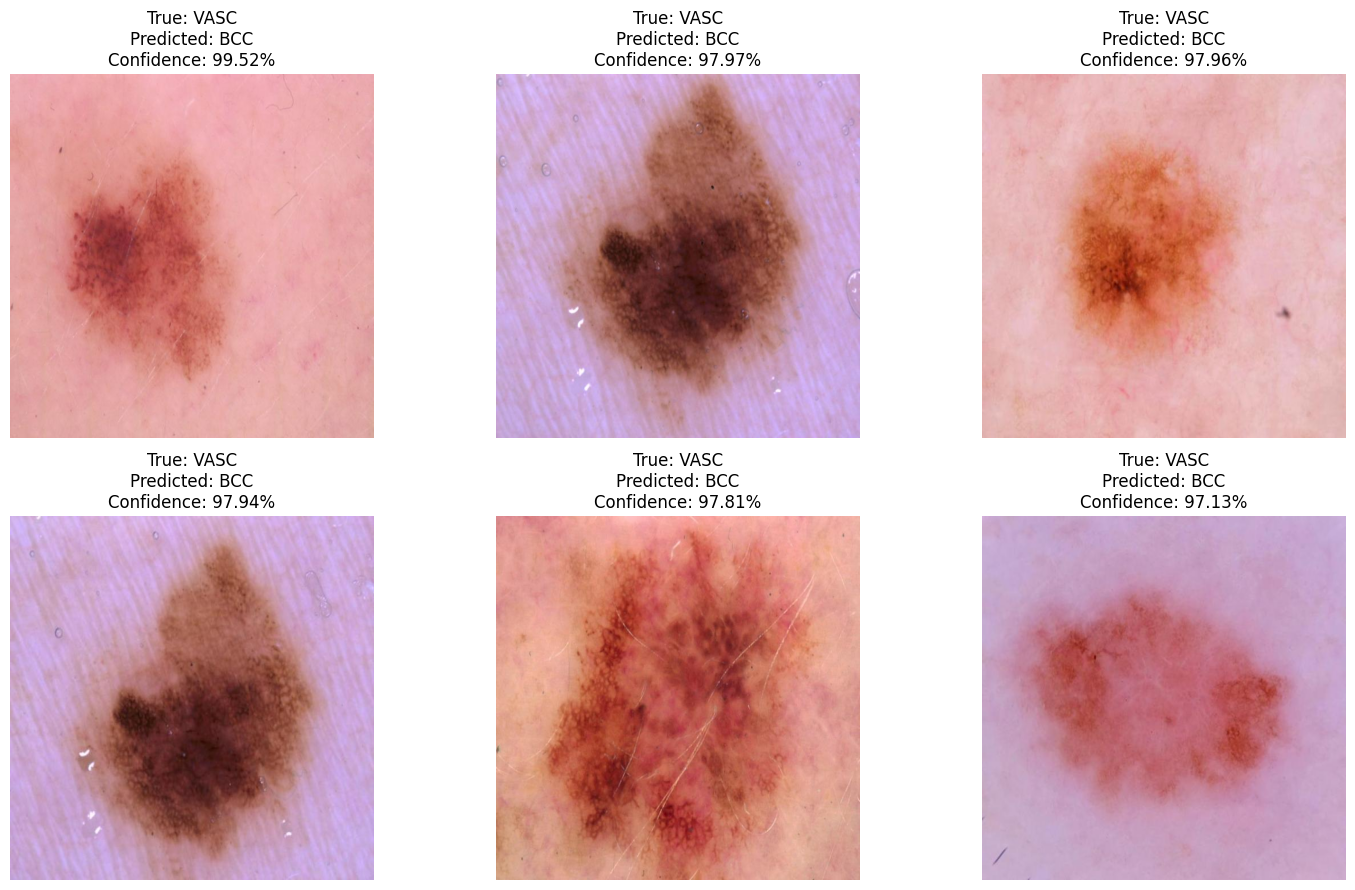

In [31]:
# Create a table containing every test prediction
classification_predictions_table = pd.DataFrame({
    "Image": [
        str(path)
        for path in test_classification_images
    ],
    "True Class": true_labels,
    "Predicted Class": predicted_labels,
    "Confidence": prediction_confidences
})

# Mark whether each prediction was correct
classification_predictions_table["Correct"] = (
    classification_predictions_table["True Class"]
    ==
    classification_predictions_table["Predicted Class"]
)

# Select the most confident incorrect predictions
failure_cases = (
    classification_predictions_table[
        classification_predictions_table["Correct"] == False
    ]
    .sort_values(
        "Confidence",
        ascending=False
    )
    .head(6)
)

print(
    "Number of incorrect test predictions:",
    (
        classification_predictions_table["Correct"] == False
    ).sum()
)

# Display the selected failure cases
if len(failure_cases) == 0:

    print("No incorrect predictions were found.")

else:

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )

    axes = axes.flatten()

    for axis, (_, row) in zip(
        axes,
        failure_cases.iterrows()
    ):

        failure_image = Image.open(
            row["Image"]
        ).convert("RGB")

        axis.imshow(failure_image)

        axis.set_title(
            f"True: {row['True Class']}\n"
            f"Predicted: {row['Predicted Class']}\n"
            f"Confidence: {row['Confidence']:.2%}"
        )

        axis.axis("off")

    for axis in axes[len(failure_cases):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

## 19. Saving Final Results

All important numerical results and prediction summaries are saved so that the final report can use outputs generated directly by this notebook.

The saved files include:

- segmentation test metrics,
- classification test predictions,
- class-wise classification metrics,
- final integrated-pipeline demonstrations, and
- dataset class distribution.

In [32]:
# Folder for final report-ready results
FINAL_RESULTS_FOLDER = Path(
    "/content/dermavision_final_results"
)

FINAL_RESULTS_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

# Save segmentation metrics
segmentation_metrics.to_csv(
    FINAL_RESULTS_FOLDER
    / "segmentation_test_metrics.csv",
    index=False
)

# Save all classification predictions
classification_predictions_table.to_csv(
    FINAL_RESULTS_FOLDER
    / "classification_test_predictions.csv",
    index=False
)

# Save class-wise classification metrics
classification_report_table.to_csv(
    FINAL_RESULTS_FOLDER
    / "classification_report.csv"
)

# Save integrated demonstration results
final_demo_table.to_csv(
    FINAL_RESULTS_FOLDER
    / "integrated_pipeline_examples.csv",
    index=False
)

# Save dataset class distribution
distribution_table.to_csv(
    FINAL_RESULTS_FOLDER
    / "class_distribution.csv"
)

print("Final result files saved:\n")

for file in sorted(FINAL_RESULTS_FOLDER.iterdir()):
    print(file.name)

Final result files saved:

class_distribution.csv
classification_report.csv
classification_test_predictions.csv
integrated_pipeline_examples.csv
segmentation_test_metrics.csv


## 21. Conclusion

This project developed **DermaVision AI**, an integrated deep-learning pipeline for skin-lesion classification and segmentation.

The project included:

- dataset validation and annotation inspection,
- class-distribution and data-quality analysis,
- transfer-learning-based segmentation,
- multiclass skin-lesion classification,
- test-set evaluation using class-wise metrics,
- confusion-matrix and failure-case analysis,
- lesion-mask visualization,
- predicted lesion-area calculation, and
- an integrated inference pipeline combining both trained models.

The classification model predicts the most likely lesion category, while the segmentation model identifies the corresponding lesion region. Combining the two outputs provides more information than either task alone.

However, the system remains an academic AI-assisted image-analysis prototype. Its predictions must not be interpreted as medical diagnoses, and clinical use would require external validation, dermatologist supervision, fairness analysis, and regulatory evaluation.

In [33]:
# Create one ZIP containing all saved metrics, plots and model outputs
import shutil
from google.colab import files

shutil.make_archive(
    "/content/DermaVision_Project_Outputs",
    "zip",
    "/content",
    base_dir="dermavision_final_results"
)

print("Output ZIP created successfully.")

files.download(
    "/content/DermaVision_Project_Outputs.zip"
)

Output ZIP created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
shutil.make_archive(
    "/content/DermaVision_Training_Runs",
    "zip",
    "/content",
    base_dir="dermavision_runs"
)

print("Training-runs ZIP created successfully.")

files.download(
    "/content/DermaVision_Training_Runs.zip"
)

Training-runs ZIP created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>